# Praktikum Pengantar Pembelajaran Mesin


---
## Bab 10. Hierarchical Clustering


## 1 ) Persiapan:

   - Pastikan perangkat dan perangkat lunak siap digunakan.
   - Import pustaka yang dibutuhkan (jika belum tersedia):


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy as sp

Untuk uji coba pertama, gunakan dataset sederhana berikut:

In [2]:
data = {'X': [1, 2, 5, 6, 8],
        'Y': [1, 1, 5, 6, 8]}

df = pd.DataFrame(data)
print(df)

   X  Y
0  1  1
1  2  1
2  5  5
3  6  6
4  8  8


## 2 ) Implementasi

a. Menghitung Matriks Jarak

In [4]:
from scipy.spatial.distance import pdist, squareform

jarak = pdist(df, metric='cityblock')
matriks_jarak = squareform(jarak)
print("Matriks Jarak (Manhattan):\n", matriks_jarak)

Matriks Jarak (Manhattan):
 [[ 0.  1.  8. 10. 14.]
 [ 1.  0.  7.  9. 13.]
 [ 8.  7.  0.  2.  6.]
 [10.  9.  2.  0.  4.]
 [14. 13.  6.  4.  0.]]


b. Hierarchical Clustering (Single Linkage & Complete Linkage)

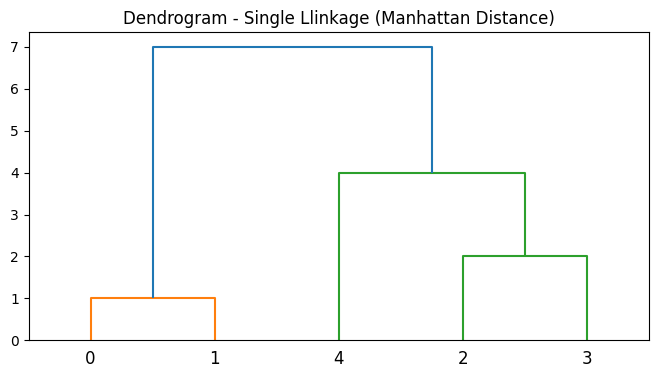

In [5]:
from scipy.cluster.hierarchy import linkage, dendrogram

# Single Linkage
linked_single = linkage(df, method='single', metric='cityblock')
plt.figure(figsize=(8, 4))
dendrogram(linked_single,
           labels=df.index,
           orientation='top')
plt.title('Dendrogram - Single Llinkage (Manhattan Distance)')
plt.show()

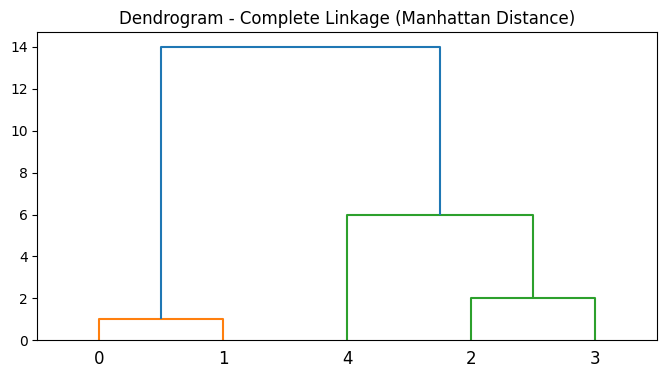

In [6]:
# Complete Linkage

linked_complete = linkage(df, method='complete', metric='cityblock')
plt.figure(figsize=(8, 4))
dendrogram(linked_complete,
           labels=df.index,
           orientation='top')
plt.title('Dendrogram - Complete Linkage (Manhattan Distance)')
plt.show()

c. Menentukan Kelompok (Optional - jika ingin memotong dendogram)

In [7]:
from scipy.cluster.hierarchy import fcluster

# Membagi hasil clustering menjadi 2 cluster
cluster_labels = fcluster(linked_single, 2, criterion='maxclust')
df['Cluster'] = cluster_labels
print(df)

   X  Y  Cluster
0  1  1        1
1  2  1        1
2  5  5        2
3  6  6        2
4  8  8        2


## TUGAS

1 ) Jelaskan perbedaan hasil clustering antara metode Single Linkage dan Complete Linkage berdasarkan dendogram yang dihasilkan!

**Jawaban**
1.  **Metode Pengukuran (Linkage):**
    *   **Single Linkage (Nearest Neighbor):** Menghitung jarak antara dua klaster berdasarkan jarak **terdekat** antara anggota-anggotanya. Metode ini cenderung menghasilkan struktur klaster yang memanjang (efek rantai atau *chaining*).
    *   **Complete Linkage (Farthest Neighbor):** Menghitung jarak antara dua klaster berdasarkan jarak **terjauh** antara anggota-anggotanya. Metode ini cenderung menghasilkan klaster yang lebih padat, bulat, dan berukuran serupa.

2.  **Berdasarkan Dendrogram yang Dihasilkan:**
    *   Pada **Single Linkage**, terdapat penggabungan titik-titik (seperti indeks 2, 3, dan 4) terjadi pada tingkat jarak (sumbu Y) yang lebih rendah (Y = 7) dibandingkan Complete Linkage (Y = 14).
    *   Pada **Complete Linkage**, tinggi garis horizontal (jarak penggabungan) lebih besar karena ia harus memastikan semua anggota di satu klaster 'dekat' dengan semua anggota di klaster lainnya berdasarkan kriteria jarak terjauh.

2 ) Uji algoritma Anda pada dataset Iris dan laporkan hasilnya!

In [13]:
# Mengunduh dataset Iris langsung dari repositori GitHub
url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv'
iris_df = pd.read_csv(url)

iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [31]:
iris_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sepal_length      150 non-null    float64
 1   sepal_width       150 non-null    float64
 2   petal_length      150 non-null    float64
 3   petal_width       150 non-null    float64
 4   species           150 non-null    object 
 5   Cluster_Single    150 non-null    int32  
 6   Cluster_Complete  150 non-null    int32  
dtypes: float64(4), int32(2), object(1)
memory usage: 7.2+ KB


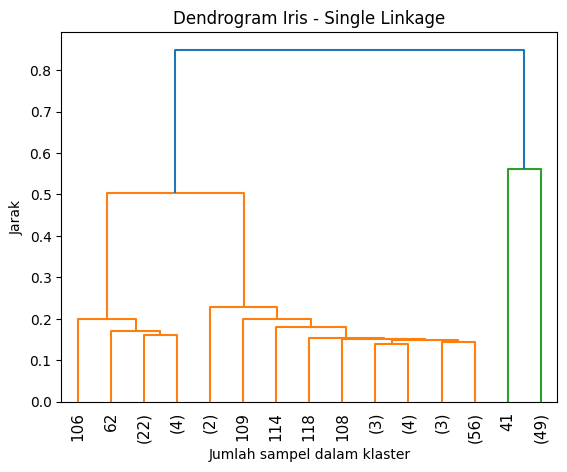

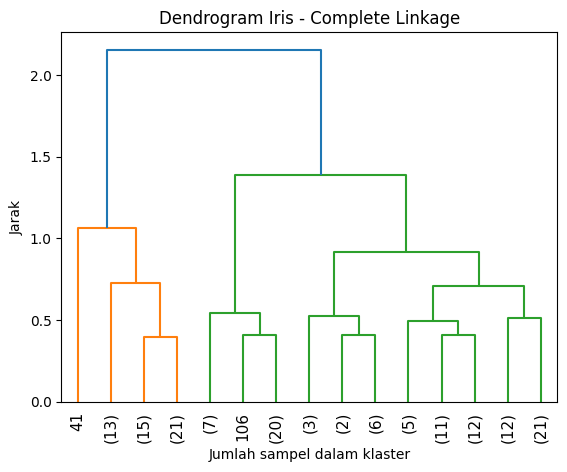

In [29]:
from sklearn.preprocessing import MinMaxScaler

# Memisahkan fitur numerik dari target (karena spesies bukan angka)
iris_numeric = iris_df.drop(columns=['species'])

# Normalisasi data (Min-Max Scaling)
scaler = MinMaxScaler()
iris_data_scaled = scaler.fit_transform(iris_numeric)

# Hierarchical Clustering (Single & Complete Linkage)
linked_single = linkage(iris_data_scaled, method='single', metric='euclidean')
linked_complete = linkage(iris_data_scaled, method='complete', metric='euclidean')

# Visualisasi Dendrogram
# Plot Single Linkage
dendrogram(linked_single,
           truncate_mode='lastp',
           p=15,
           leaf_rotation=90.,
           leaf_font_size=11.)
plt.title('Dendrogram Iris - Single Linkage')
plt.xlabel('Jumlah sampel dalam klaster')
plt.ylabel('Jarak')
plt.show()

print()

# Plot Complete Linkage
dendrogram(linked_complete,
           truncate_mode='lastp',
           p=15,
           leaf_rotation=90.,
           leaf_font_size=11.)
plt.title('Dendrogram Iris - Complete Linkage')
plt.xlabel('Jumlah sampel dalam klaster')
plt.ylabel('Jarak')
plt.show()

**Penjelasan Kode Program**

Secara umum, kode menjalankan proses Hierarchical Clustering dengan langkah-langkah utama sebagai berikut:

1. Pemisahan Fitur Numerik: Kode `iris_df.drop(columns=['species'])`
  digunakan untuk membuang kolom target (spesies). Ini wajib dilakukan karena algoritma clustering bekerja dengan menghitung jarak matematis, sehingga hanya membutuhkan data berupa angka (numerik), bukan label teks.

2. Normalisasi Data: Menggunakan MinMaxScaler untuk mengubah rentang semua angka pada data menjadi skala yang sama (dari 0 hingga 1). Langkah ini sangat penting agar fitur yang memiliki angka lebih besar (seperti Sepal Length) tidak mendominasi perhitungan jarak dibandingkan fitur yang angkanya kecil (seperti Petal Width).

3. Proses Hierarchical Clustering (Linkage): Kode menjalankan algoritma clustering menggunakan fungsi `linkage()` dengan ukuran jarak euclidean.

   a. Single Linkage: Menggabungkan cluster berdasarkan jarak terdekat antar anggota cluster.

   b. Complete Linkage: Menggabungkan cluster berdasarkan jarak terjauh antar anggota cluster.

4. Visualisasi Dendrogram: Menampilkan pohon clustering (dendrogram). Karena dataset Iris cukup besar (150 data), ditambahkan penggunaan parameter `truncate_mode='lastp'` dan `p=15`. Artinya, memotong pohon tersebut dan hanya menampilkan 15 penggabungan terakhir di sumbu X agar visualisasinya rapi, dapat dibaca, dan tidak saling menumpuk.

**Analisis Dendrogram Single Linkage**

1. Efek Rantai (Chaining Effect): Pada grafik Single Linkage, terlihat sangat jelas adanya efek berantai. Algoritma cenderung menggabungkan satu persatu data individual ke dalam satu kelompok besar yang sudah ada, sehingga bentuk pohonnya terlihat miring ke satu sisi seperti tangga.

2. Jarak Penggabungan (Sumbu Y): Proses penggabungan terjadi pada jarak yang sangat kecil (maksimal hanya sekitar 0.55).

3. **Kesimpulan:** Metode Single Linkage kurang cocok dan kurang ideal untuk membagi data Iris menjadi 3 kelompok utama yang seimbang, karena kelompok yang terbentuk cenderung menumpuk menjadi satu klaster raksasa.

B. Analisis Dendrogram Complete Linkage

1. Struktur Klaster yang Berimbang: Berbeda dengan Single Linkage, grafik Complete Linkage menunjukkan pembentukan cabang-cabang kelompok yang strukturnya jauh lebih rapi, padat (compact), dan seimbang ukurannya.

2. Jarak Penggabungan (Sumbu Y): Jarak antar klasternya jauh lebih tegas (Sumbu Y mencapai angka sekitar 1.4).

3. **Kesimpulan:** Metode Complete Linkage memberikan hasil yang sangat baik. Jika kita menarik garis potong mendatar (horizontal) pada sumbu Y di angka sekitar 0.8, kita bisa dengan sangat jelas membagi keseluruhan data menjadi 3 klaster utama. Ini sangat sesuai dengan karakteristik dataset Iris asli yang memang terdiri dari 3 spesies bunga.

3 ) Analisis kelebihan dan kekurangan metode Hierarchical Clustering dibandingkan K-Means dan DBSCAN!

**Jawaban**

Kelebihan Hierarchical Clustering:

1. HC Tidak Perlu Menentukan Jumlah Klaster (K) di Awal (vs K-Means). Pada K-Means, kita harus menebak dan menentukan jumlah klaster ($K$) sejak awal sebelum algoritma berjalan. Pada HC, kita tidak perlu melakukannya, cukup membiarkan algoritma membentuk pohon (dendrogram) terlebih dahulu, baru kemudian kita memutuskan ingin memotongnya menjadi berapa klaster berdasarkan visualisasi tersebut.

2. HC menghasilkan Dendrogram, yaitu grafik pohon yang menunjukkan bagaimana setiap data saling berhubungan secara hierarki. Baik K-Means maupun DBSCAN tidak memiliki fitur visualisasi bawaan sebaik ini untuk melihat kedekatan antar individu data.

3. Jika data secara alami memiliki sub-kelompok (misalnya klasifikasi taksonomi hewan/tumbuhan dari kingdom hingga spesies), HC adalah pilihan terbaik karena memang dirancang untuk kebutuhan tersebut.

Kekurangan Hierarchical Clustering:

1. HC menghitung jarak dari setiap data ke setiap data lainnya. Jika dataset punya jutaan baris data, HC akan memakan memori (RAM) yang luar biasa besar dan waktu komputasi yang sangat lama. Untuk data berukuran raksasa, K-Means jauh lebih unggul, cepat, dan efisien.

2. Algoritma HC (terutama Single Linkage) sangat mudah terpengaruh oleh outlier yang dapat merusak struktur kelompok. Sebaliknya, DBSCAN adalah algoritma yang paling tepat dalam menangani outlier karena DBSCAN secara otomatis akan membuang outlier dan menganggapnya sebagai noise.

3. Dalam HC, jika dua kelompok sudah terlanjur digabungkan pada suatu langkah, algoritma tidak bisa mundur untuk memisahkan mereka lagi meskipun ternyata di langkah selanjutnya penggabungan itu terbukti kurang tepat. K-Means lebih dinamis karena titik pusat (centroid) terus bergerak memperbaiki posisinya di setiap iterasi.

4. Jika bentuk pengelompokan data  melengkung, berbentuk cincin, atau tidak beraturan, HC (dan juga K-Means) seringkali gagal mengelompokkannya dengan benar. DBSCAN adalah yang paling tepat dalam mencari cluster berdasarkan kepadatan (density), sehingga bentuk abstrak apa pun bisa dideteksi dengan baik.

## Kesimpulan

Berdasarkan praktikum mengenai Hierarchical Clustering, dapat ditarik kesimpulan sebagai berikut:

1. Pencapaian Tujuan Percobaan
Tujuan percobaan telah tercapai dengan baik. Praktikum ini telah berhasil menerapkan, memvisualisasikan, dan membandingkan performa dari berbagai algoritma clustering (termasuk penyesuaian visualisasi Hierarchical Clustering menggunakan truncate mode agar lebih mudah dianalisis) menggunakan dataset Iris.

2. Hubungan Antara Hasil Percobaan dan Dasar Teori
Hasil eksperimen sangat sejalan dengan dasar teori yang ada:

   a. Hierarchical Clustering
   
   Teori menyebutkan bahwa Single Linkage rentan terhadap chaining effect (efek rantai), yang terbukti dari bentuk dendrogram yang miring menumpuk. Sebaliknya, Complete Linkage secara teori membentuk kelompok yang lebih padat dan tegas, yang terbukti dapat membagi data Iris menjadi 3 kelompok utama yang seimbang (sesuai dengan 3 spesies asli bunga Iris).

   b. Perhitungan Jarak
   
   Teori clustering yang menggunakan metrik jarak (seperti Euclidean) mewajibkan data berskala seragam. Hal ini terbukti dari langkah penerapan MinMaxScaler yang berhasil membuat algoritma bekerja dengan akurat tanpa bias pada fitur tertentu.

3. Faktor-Faktor yang Memengaruhi Hasil dan Kemungkinan Kesalahan
Beberapa faktor krusial yang menentukan keberhasilan percobaan ini meliputi:

   a. Tahap Prapemrosesan (Preprocessing):
   
   Tidak membuang kolom target atau gagal melakukan normalisasi skala (Scaling) adalah kesalahan fatal yang akan membuat perhitungan jarak menjadi tidak valid dan merusak hasil clustering.

   b. Pemilihan Parameter dan Metode
   
   Kesalahan dalam memilih metode, misalnya memaksakan penggunaan Single Linkage untuk mencari klaster yang seimbang, akan menyebabkan kegagalan interpretasi.

   c. Kepadatan Visualisasi
   Pada data yang cukup besar (seperti 150 baris data Iris atau data lain yang jauh lebih besar), tidak menggunakan parameter pemotongan (truncate_mode) pada fungsi dendrogram akan menyebabkan teks di sumbu X menumpuk, sehingga data sama sekali tidak bisa dibaca maupun dianalisis.